In [43]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler

In [44]:
def load_data(files, symbols):
    dfs = []
    for file, symbol in zip(files, symbols):
        df = pd.read_parquet(file)
        df['symbol'] = symbol  # Add the symbol column for each stock
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# List of files for multiple stocks and their symbols
files = ["data/2024_XIU.parquet", "data/2024_TD.parquet", "data/2024_BMO.parquet", "data/2024_BNS.parquet", "data/2024_RY.parquet"]
symbols = ["XIU", "TD", "BMO", "BNS", "RY"]

df = load_data(files, symbols)

# Define option expiration date
options_day = datetime.strptime("2024-12-31", "%Y-%m-%d")

# Calculate daily returns (assuming the 'underlying_price' column exists)
df['change_percent'] = df['underlying_price'].pct_change() * 100

# Compute annualized volatility using daily returns
annualized_volatility = df['change_percent'].std() * math.sqrt(250)  # 250 Canadian trading days

# Prepare dataframe with required parameters
df["T"] = df["dte"] / 365  # Time to maturity in years
df["sigma"] = annualized_volatility
df["r"] = 0.05  # Assuming a constant risk-free rate of 5%
df["S0"] = df["underlying_price"]
df["K"] = df["strike"]

scaler = MinMaxScaler()

# Filter for put options within 30-60 days to expiration
puts = df[df["option_type"] == "put"]
puts_monthly['normalized_binomial_price'] = scaler.fit_transform(puts_monthly[['binomial_price']])

In [45]:
# Define the binomial tree function (same as before)
def binomial_tree_american_put(S0, K, r, sigma, T, M):
    dt = T / M
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)  # Risk-neutral probability
    discount = np.exp(-r * dt)

    # Stock prices at maturity
    stock_prices = np.asarray([S0 * (u ** j) * (d ** (M - j)) for j in range(M + 1)])
    option_values = np.maximum(K - stock_prices, 0)

    # Backward induction
    for t in range(M - 1, -1, -1):
        option_values = discount * (p * option_values[1:] + (1 - p) * option_values[:-1])
        stock_prices = stock_prices[:-1] / u  # Move back one step
        option_values = np.maximum(option_values, K - stock_prices)  # Check early exercise

    return option_values[0]

# Compute binomial tree prices for each stock
def binomial_tree_batched(S0, K, r, sigma, T, M=50, batch_size=1000):
    S0 = np.atleast_1d(S0)
    K = np.atleast_1d(K)
    r = np.atleast_1d(r)
    sigma = np.atleast_1d(sigma)
    T = np.atleast_1d(T)

    L = len(S0)
    results = np.zeros(L)

    for i in range(0, L, batch_size):
        batch_end = min(i + batch_size, L)
        results[i:batch_end] = [
            binomial_tree_american_put(S0[j], K[j], r[j], sigma[j], T[j], M) for j in range(i, batch_end)
        ]

    return results



# Model Parameters
M = 50
batch_size = 1000

# Compute Binomial Tree Prices
puts_monthly["binomial_price"] = binomial_tree_batched(
    puts_monthly["S0"].values, puts_monthly["K"].values,
    puts_monthly["r"].values, puts_monthly["sigma"].values,
    puts_monthly["T"].values, M, batch_size
)



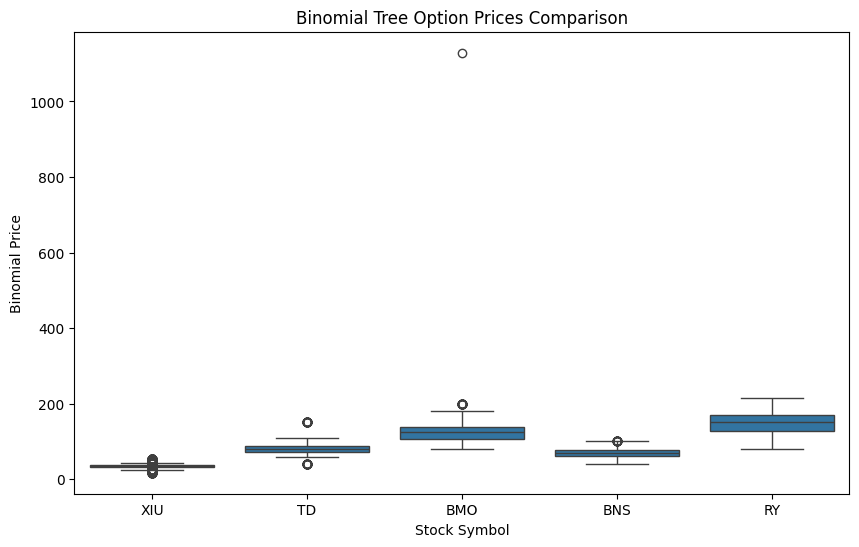

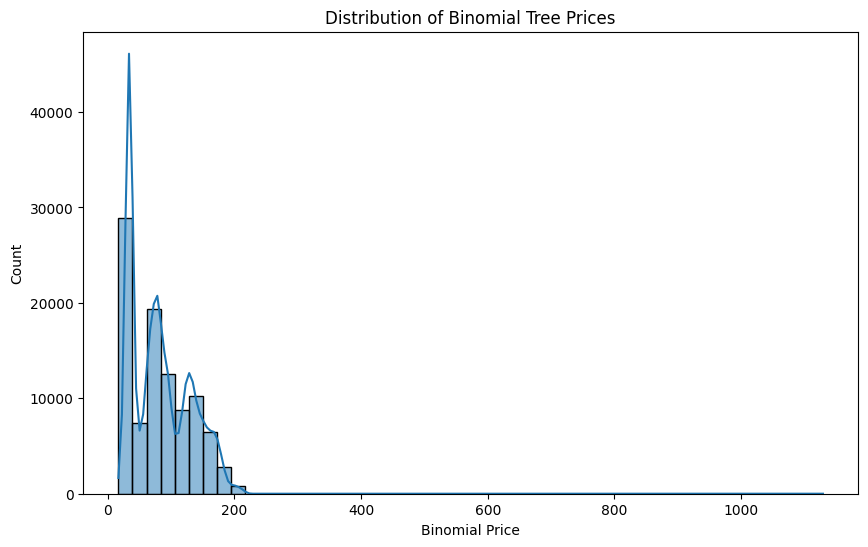

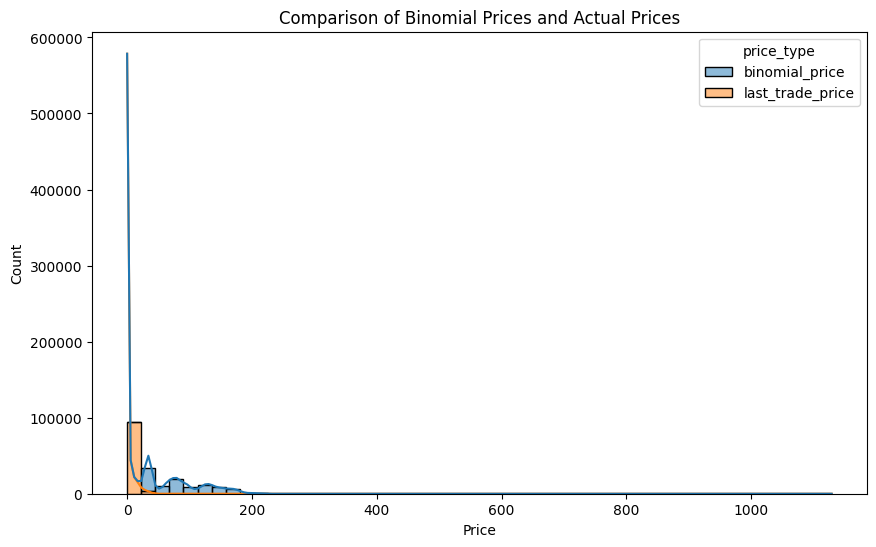

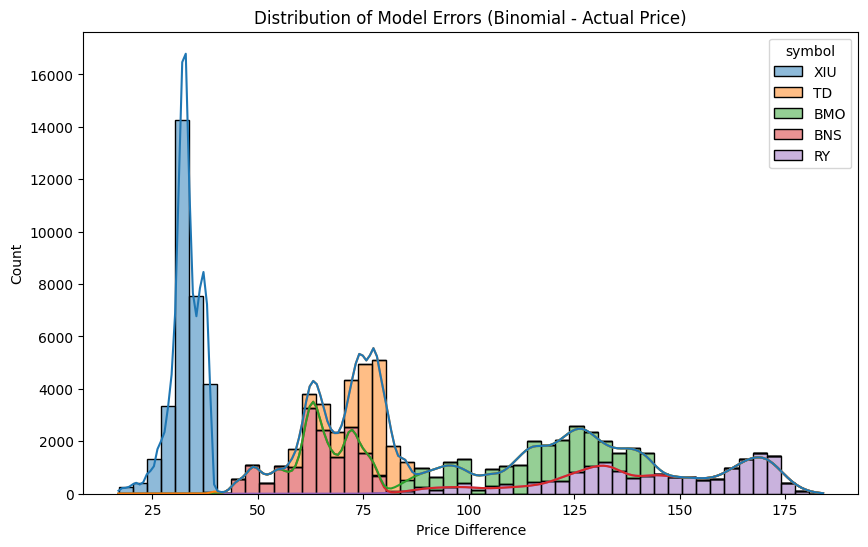

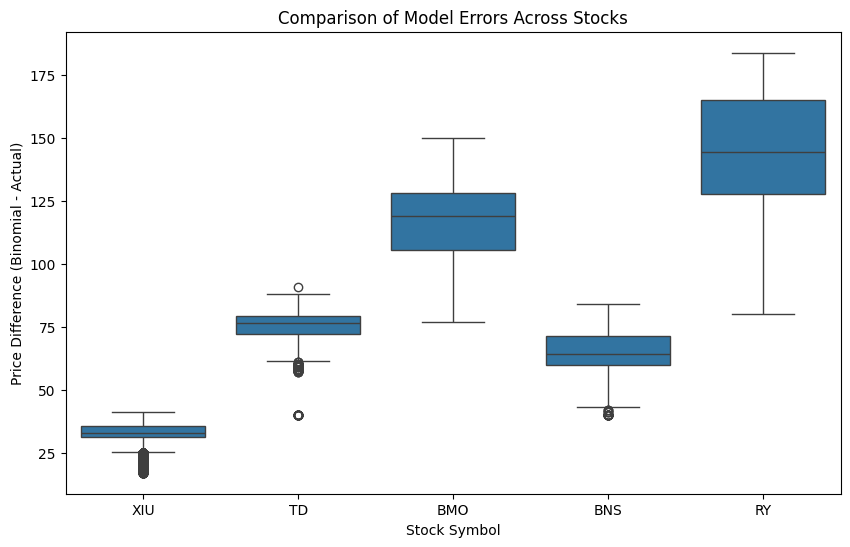

In [46]:
# Ensure required columns exist
required_columns = ["binomial_price", "last_trade_price", "symbol"]
for col in required_columns:
    if col not in puts_monthly.columns:
        raise KeyError(f"Column '{col}' not found in DataFrame")

# Boxplot: Binomial Prices for Different Stocks
plt.figure(figsize=(10, 6))
sns.boxplot(x="symbol", y="binomial_price", data=puts_monthly)
plt.title("Binomial Tree Option Prices Comparison")
plt.xlabel("Stock Symbol")
plt.ylabel("Binomial Price")
plt.show()

# Histogram: Distribution of Binomial Prices
plt.figure(figsize=(10, 6))
sns.histplot(puts_monthly["binomial_price"], bins=50, kde=True)
plt.title("Distribution of Binomial Tree Prices")
plt.xlabel("Binomial Price")
plt.ylabel("Count")
plt.show()

# Convert to long format for price comparison
puts_long = puts_monthly.melt(id_vars=["symbol"], value_vars=["binomial_price", "last_trade_price"],
                              var_name="price_type", value_name="price")

# Histogram: Comparing Binomial Prices and Last Trade Prices
plt.figure(figsize=(10, 6))
sns.histplot(puts_long, x="price", hue="price_type", multiple="stack", bins=50, kde=True)
plt.title("Comparison of Binomial Prices and Actual Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# Price Difference Calculation
puts_monthly["price_diff"] = puts_monthly["binomial_price"] - puts_monthly["last_trade_price"]

# Histogram: Model Errors (Binomial Price - Actual Price)
plt.figure(figsize=(10, 6))
sns.histplot(puts_monthly, x="price_diff", hue="symbol", multiple="stack", bins=50, kde=True)
plt.title("Distribution of Model Errors (Binomial - Actual Price)")
plt.xlabel("Price Difference")
plt.ylabel("Count")
plt.show()

# Boxplot: Model Errors Across Stocks
plt.figure(figsize=(10, 6))
sns.boxplot(x="symbol", y="price_diff", data=puts_monthly)
plt.title("Comparison of Model Errors Across Stocks")
plt.xlabel("Stock Symbol")
plt.ylabel("Price Difference (Binomial - Actual)")
plt.show()